# FraudScope — 02 MLOps : Tracking, Registry & Serving
## Phase 2 · Dataset IEEE-CIS · MLflow · XGBoost · SHAP

**Objectifs de ce notebook** :
1. Installer et configurer MLflow comme serveur de tracking
2. Comparer 5 stratégies de resampling sur XGBoost avec **validation croisée temporelle** (`TimeSeriesSplit`)
3. Identifier le meilleur modèle et l'enregistrer dans le MLflow Model Registry
4. Servir le modèle via une API REST
5. Expliquer les prédictions avec SHAP et logger les artefacts

**Prérequis** : avoir complété `01_exploration.ipynb` et suivi `docs/phase2_mlflow_guide.md`.

> ⚠️ Le serveur MLflow doit être lancé **avant** d'exécuter ce notebook :
> ```
> mlflow server --host 127.0.0.1 --port 8080 --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlartifacts
> ```

## 0. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import (
    recall_score, f1_score, average_precision_score,
    precision_recall_curve
)

import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

import shap

# ── Configuration ─────────────────────────────────────────────
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

FIGURES_DIR   = Path('figures')
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TARGET       = 'isFraud'
N_SPLITS_TSS = 5   # Nombre de folds pour TimeSeriesSplit

# Numérotation des steps MLflow :
#   Steps 1..N_SPLITS_TSS  : métriques de chaque fold CV
#   Step N_SPLITS_TSS + 1  : agrégées CV (moyenne/std) → STEP_AGG
#   Step N_SPLITS_TSS + 2  : évaluation holdout         → STEP_FINAL
STEP_AGG   = N_SPLITS_TSS + 1  # step agrégation CV
STEP_FINAL = N_SPLITS_TSS + 2  # step évaluation holdout

# ── MLflow setup ─────────────────────────────────────────────
load_dotenv()

TRACKING_URI        = os.getenv('MLFLOW_TRACKING_URI', 'http://127.0.0.1:8080')
EXPERIMENT_NAME     = os.getenv('MLFLOW_EXPERIMENT_NAME', 'fraud-detection-paytrack')
MODEL_REGISTRY_NAME = 'FraudScopeXGB'

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'MLflow tracking URI : {TRACKING_URI}')
print(f'Expérience          : {EXPERIMENT_NAME}')
print(f'MLflow version      : {mlflow.__version__}')
print('Imports OK')

MLflow tracking URI : http://127.0.0.1:8080
Expérience          : fraud-detection-paytrack
MLflow version      : 3.14.0
Imports OK


## 1. Chargement et préparation des données

On réutilise les mêmes données que la Phase 1.
Les features de vélocité sont recalculées ici pour être disponibles dans ce notebook.

In [2]:
DATA_DIR = Path('data')

assert (DATA_DIR / 'train_transaction.csv').exists(), 'Données manquantes → voir data/get_dataset.md'

print('Chargement des données...')
train_tx = pd.read_csv(DATA_DIR / 'train_transaction.csv')
train_id = pd.read_csv(DATA_DIR / 'train_identity.csv')

df = train_tx.merge(train_id, on='TransactionID', how='left')
df = df.sort_values('TransactionDT').reset_index(drop=True)
print(f'Dataset : {df.shape[0]:,} transactions, {df.shape[1]} colonnes')

def reduce_mem_usage(df):
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        col_min, col_max = df[col].min(), df[col].max()
        if str(df[col].dtype).startswith('int'):
            if   col_min >= np.iinfo(np.int8).min  and col_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            else:
                df[col] = df[col].astype(np.int32)
        else:
            if col_min >= np.finfo(np.float32).min and col_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    return df

df = reduce_mem_usage(df)
print('Downcast mémoire appliqué.')

Chargement des données...
Dataset : 590,540 transactions, 434 colonnes
Downcast mémoire appliqué.


In [3]:
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  =  df['TransactionDT'] // (3600 * 24)

proxy_cols = [c for c in ['card1','card2','card3','card4','card5','card6','addr1','addr2'] if c in df.columns]
df['customer_proxy'] = df[proxy_cols].astype(str).fillna('NA').agg('_'.join, axis=1)
df['tx_time_sec']    = df['TransactionDT'].astype(float)

df['tx_rank_in_customer'] = df.groupby('customer_proxy').cumcount()

df['amount_ratio'] = df['TransactionAmt'] / (
    df.groupby('customer_proxy')['TransactionAmt']
    .transform('median')
    .clip(lower=0.01)
)
df['amount_ratio'] = df['amount_ratio'].replace([np.inf, -np.inf], 1.0).fillna(1.0)

print('Features temporelles et vélocité créées.')

Features temporelles et vélocité créées.


## 2. Préparation du pipeline de prétraitement

Le dataset est trié chronologiquement (`TransactionDT`). On construit :
- Un **holdout temporel** (20% final) réservé à l'évaluation finale — il ne participera jamais à l'entraînement ni à la sélection de modèle.
- Un **jeu d'entraînement** (80% initial) sur lequel la cross-validation temporelle `TimeSeriesSplit` sera appliquée.

**Pourquoi `TimeSeriesSplit` plutôt que `KFold` ?** Avec des séries temporelles, le fold de validation doit toujours être *postérieur* au fold d'entraînement — sinon on introduit un data leakage futur (le modèle "verrait" des transactions futures pour prédire le passé). `TimeSeriesSplit` garantit cette causalité.

In [4]:
exclude = {'TransactionID', TARGET, 'customer_proxy', 'tx_time_sec'}
high_missing = df.columns[df.isna().mean() > 0.95].tolist()
all_features = [c for c in df.columns if c not in exclude and c not in high_missing]

X = df[all_features]
y = df[TARGET]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Features numériques   : {len(num_features)}')
print(f'Features catégorielles : {len(cat_features)}')
print(f'Total                 : {len(all_features)}')

num_transformer = SimpleImputer(strategy='median')

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features),
], remainder='drop')

# ── Holdout temporel : 20% les plus récentes, jamais utilisées en CV ──
holdout_idx = int(len(df) * 0.8)
X_cv_raw,  X_holdout_raw = X.iloc[:holdout_idx], X.iloc[holdout_idx:]
y_cv,      y_holdout     = y.iloc[:holdout_idx], y.iloc[holdout_idx:]

print(f'\nHoldout temporel final : {len(y_holdout):,} transactions (20% les plus récentes)')
print(f"Jeu d'entraînement CV  : {len(y_cv):,} transactions (80% les plus anciennes)")
print(f'Ratio fraude train : {y_cv.mean():.4f}  |  holdout : {y_holdout.mean():.4f}')

# ── Prétraitement du holdout (fit uniquement sur les données CV) ──
X_cv      = preprocessor.fit_transform(X_cv_raw)
X_holdout = preprocessor.transform(X_holdout_raw)

# ── Aperçu des folds TimeSeriesSplit ──
tss = TimeSeriesSplit(n_splits=N_SPLITS_TSS)
print(f"\nSchéma TimeSeriesSplit (N_SPLITS={N_SPLITS_TSS}) sur le jeu d'entraînement :")
for fold, (tr_idx, val_idx) in enumerate(tss.split(X_cv), 1):
    print(f'  Fold {fold} — train: {len(tr_idx):,} tx  |  val: {len(val_idx):,} tx')

Features numériques   : 398
Features catégorielles : 29
Total                 : 427

Holdout temporel final : 118,108 transactions (20% les plus récentes)
Jeu d'entraînement CV  : 472,432 transactions (80% les plus anciennes)
Ratio fraude train : 0.0351  |  holdout : 0.0344

Schéma TimeSeriesSplit (N_SPLITS=5) sur le jeu d'entraînement :
  Fold 1 — train: 78,742 tx  |  val: 78,738 tx
  Fold 2 — train: 157,480 tx  |  val: 78,738 tx
  Fold 3 — train: 236,218 tx  |  val: 78,738 tx
  Fold 4 — train: 314,956 tx  |  val: 78,738 tx
  Fold 5 — train: 393,694 tx  |  val: 78,738 tx


## 3. Comparaison des stratégies de resampling avec MLflow

On compare 5 stratégies pour gérer le déséquilibre de classes :

| # | Stratégie | Principe |
|---|-----------|----------|
| 1 | **Baseline** | Aucun resampling — XGBoost sur données brutes |
| 2 | **Class weighting** | `scale_pos_weight` = nb_négatifs / nb_positifs |
| 3 | **Undersampling** | Réduction aléatoire de la classe majoritaire |
| 4 | **SMOTE** | Génération synthétique d'exemples frauduleux |
| 5 | **SMOTE+ENN** | SMOTE + nettoyage des frontières de décision |

**Protocole** : chaque stratégie est évaluée via `TimeSeriesSplit(n_splits=5)`. Le resampling est appliqué **uniquement sur le fold d'entraînement** de chaque itération — jamais sur le fold de validation — pour éviter tout data leakage.

**Logging MLflow par step** : les métriques de chaque fold sont loggées au step correspondant (fold 1 → step 1, …, fold 5 → step 5). Les agrégées CV sont loggées au step `N_SPLITS_TSS + 1` (`STEP_AGG`) et l'évaluation finale sur le holdout au step `N_SPLITS_TSS + 2` (`STEP_FINAL`). Cela permet de visualiser toute la chronologie d'un entraînement dans un seul graphe MLflow.

**Ratio d'imbalance par fold** : le ratio négatifs/positifs est recalculé à l'intérieur de chaque fold, depuis `y_fold_train` uniquement.

In [5]:
XGB_BASE_PARAMS = {
    'n_estimators':     300,
    'max_depth':        6,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'eval_metric':      'aucpr',
    'early_stopping_rounds': 20,
    'random_state':     RANDOM_STATE,
    'n_jobs':           -1
}

# Affiché à titre informatif uniquement — plus utilisé dans le pipeline
neg_global = (y_cv == 0).sum()
pos_global = (y_cv == 1).sum()
print(f"Ratio déséquilibre sur l'ensemble du jeu CV (indicatif) : {neg_global / pos_global:.1f}  ({neg_global:,} légitimes / {pos_global:,} fraudes)")
print("Note : le ratio exact de chaque fold est calculé dynamiquement dans apply_resampling.")

Ratio déséquilibre sur l'ensemble du jeu CV (indicatif) : 27.5  (455,833 légitimes / 16,599 fraudes)
Note : le ratio exact de chaque fold est calculé dynamiquement dans apply_resampling.


In [6]:
def apply_resampling(strategy_name, X_fold_train, y_fold_train, extra_params):
    """Applique la stratégie de resampling sur un fold d'entraînement.
    Retourne (X_resampled, y_resampled, extra_xgb_params).

    Le resampling n'est JAMAIS appliqué au fold de validation.

    Le ratio d'imbalance est calculé ici depuis y_fold_train, garantissant
    que scale_pos_weight reflète la distribution réelle du fold courant
    (et non un ratio global calculé sur l'ensemble du jeu CV).
    Ceci est correct aussi pour le refit final : appelé avec y_cv complet,
    le ratio est alors celui de l'ensemble du jeu d'entraînement.
    """
    from imblearn.under_sampling import RandomUnderSampler

    # Ratio calculé depuis le fold courant (ou y_cv complet lors du refit final)
    fold_neg = (y_fold_train == 0).sum()
    fold_pos = (y_fold_train == 1).sum()
    fold_ratio = fold_neg / fold_pos  # négatifs / positifs

    if strategy_name == 'baseline':
        return X_fold_train, y_fold_train, extra_params

    elif strategy_name == 'class_weighting':
        # scale_pos_weight = ratio exact de ce fold
        params = {**extra_params, 'scale_pos_weight': fold_ratio}
        return X_fold_train, y_fold_train, params

    elif strategy_name == 'undersampling':
        X_res, y_res = RandomUnderSampler(
            sampling_strategy=0.1, random_state=RANDOM_STATE
        ).fit_resample(X_fold_train, y_fold_train)
        return X_res, y_res, extra_params

    elif strategy_name == 'smote':
        X_res, y_res = SMOTE(
            sampling_strategy=0.2, random_state=RANDOM_STATE
        ).fit_resample(X_fold_train, y_fold_train)
        return X_res, y_res, extra_params

    elif strategy_name == 'smote_enn':
        # Fix MemoryError : sampling_strategy 0.1 + cast float32 pour limiter l'empreinte mémoire
        X_f32 = X_fold_train.astype(np.float32)
        X_res, y_res = SMOTEENN(
            sampling_strategy=0.1, random_state=RANDOM_STATE
        ).fit_resample(X_f32, y_fold_train)
        return X_res, y_res, extra_params

    else:
        raise ValueError(f'Stratégie inconnue : {strategy_name}')


def run_strategy(strategy_name, X_cv, y_cv, extra_params=None):
    """Entraîne XGBoost avec TimeSeriesSplit(n_splits=5) et logue dans MLflow.

    Stratégie de logging par step :
      - Steps 1..N_SPLITS_TSS : métriques du fold correspondant (AUPRC, recall_fraud, f1,
        imbalance_ratio). Toutes les métriques d'un même fold partagent le même step.
      - Step N_SPLITS_TSS + 1 (STEP_AGG)   : agrégées CV (AUPRC/recall/f1 = moyennes,
        AUPRC_std, fit_time_sec, imbalance_ratio).
      - Step N_SPLITS_TSS + 2 (STEP_FINAL) : évaluation holdout (AUPRC, recall_fraud, f1).
      - Les métriques agrégées nommées explicitement (`AUPRC_cv_mean`, etc.) restent
        loggées sans step pour `search_runs()` et la comparaison de runs dans l'UI.
    """
    extra_params = extra_params or {}
    tss = TimeSeriesSplit(n_splits=N_SPLITS_TSS)

    fold_auprc, fold_recall, fold_f1, fold_ratios = [], [], [], []

    with mlflow.start_run(run_name=f'xgb-{strategy_name}') as run:

        mlflow.set_tags({'dataset': 'IEEE-CIS', 'model': 'XGBoost',
                         'strategy': strategy_name, 'phase': '2',
                         'cv_method': f'TimeSeriesSplit(n_splits={N_SPLITS_TSS})'})
        mlflow.log_param('n_splits_tss', N_SPLITS_TSS)
        mlflow.log_params({**XGB_BASE_PARAMS, **extra_params})
        mlflow.log_param('train_size_cv', len(y_cv))
        mlflow.log_param('fraud_rate_cv', float(y_cv.mean()))

        t0 = time.time()

        # ── Boucle CV : chaque fold → un step MLflow ──────────────────────
        for fold, (tr_idx, val_idx) in enumerate(tss.split(X_cv), 1):
            X_fold_tr, y_fold_tr = X_cv[tr_idx], y_cv.iloc[tr_idx]
            X_fold_val, y_fold_val = X_cv[val_idx], y_cv.iloc[val_idx]

            X_res, y_res, fold_extra = apply_resampling(
                strategy_name, X_fold_tr, y_fold_tr, extra_params
            )

            fold_ratio = (y_fold_tr == 0).sum() / max((y_fold_tr == 1).sum(), 1)
            fold_ratios.append(fold_ratio)

            params = {**XGB_BASE_PARAMS, **fold_extra}
            model  = xgb.XGBClassifier(**params)
            model.fit(X_res, y_res,
                      eval_set=[(X_fold_val, y_fold_val)],
                      verbose=False)

            y_proba = model.predict_proba(X_fold_val)[:, 1]
            y_pred  = (y_proba >= 0.5).astype(int)

            auprc_fold  = average_precision_score(y_fold_val, y_proba)
            recall_fold = recall_score(y_fold_val, y_pred)
            f1_fold     = f1_score(y_fold_val, y_pred)

            fold_auprc.append(auprc_fold)
            fold_recall.append(recall_fold)
            fold_f1.append(f1_fold)

            # Toutes les métriques du fold au même step = fold courant
            mlflow.log_metrics({
                'AUPRC':            auprc_fold,
                'recall_fraud':     recall_fold,
                'f1':               f1_fold,
                'imbalance_ratio':  fold_ratio,
            }, step=fold)

        fit_time = time.time() - t0

        mean_auprc  = float(np.mean(fold_auprc))
        mean_recall = float(np.mean(fold_recall))
        mean_f1     = float(np.mean(fold_f1))
        std_auprc   = float(np.std(fold_auprc))

        # ── Step STEP_AGG : agrégées CV sur la timeline MLflow ───────────
        mlflow.log_metrics({
            'AUPRC':            mean_auprc,
            'recall_fraud':     mean_recall,
            'f1':               mean_f1,
            'AUPRC_std':        std_auprc,
            'fit_time_sec':     fit_time,
            'imbalance_ratio':  float(np.mean(fold_ratios)),
        }, step=STEP_AGG)

        # Métriques sans step (noms explicites) — pour search_runs / comparaison
        mlflow.log_metrics({
            'AUPRC_cv_mean':          mean_auprc,
            'AUPRC_cv_std':           std_auprc,
            'recall_fraud_cv_mean':   mean_recall,
            'f1_cv_mean':             mean_f1,
            'fit_time_sec':           fit_time,
            'imbalance_ratio_mean':   float(np.mean(fold_ratios)),
            'imbalance_ratio_std':    float(np.std(fold_ratios)),
        })

        # ── Réentraînement final sur tout X_cv pour Registry ──────────────
        X_final, y_final, final_extra = apply_resampling(
            strategy_name, X_cv, y_cv, extra_params
        )
        final_params = {**XGB_BASE_PARAMS, **final_extra}
        final_params.pop('early_stopping_rounds', None)
        final_model = xgb.XGBClassifier(**final_params)
        final_model.fit(X_final, y_final, verbose=False)

        y_proba_holdout = final_model.predict_proba(X_holdout)[:, 1]
        y_pred_holdout  = (y_proba_holdout >= 0.5).astype(int)
        auprc_holdout   = average_precision_score(y_holdout, y_proba_holdout)
        recall_holdout  = recall_score(y_holdout, y_pred_holdout)
        f1_holdout      = f1_score(y_holdout, y_pred_holdout)

        # ── Step STEP_FINAL (N_SPLITS_TSS + 2) : évaluation holdout ──────
        mlflow.log_metrics({
            'AUPRC':        auprc_holdout,
            'recall_fraud': recall_holdout,
            'f1':           f1_holdout,
        }, step=STEP_FINAL)
        mlflow.log_metric('AUPRC_holdout', auprc_holdout)

        # Courbe PR (holdout)
        precision_vals, recall_vals, _ = precision_recall_curve(y_holdout, y_proba_holdout)
        fig_pr, ax_pr = plt.subplots(figsize=(7, 5))
        ax_pr.plot(recall_vals, precision_vals, lw=2, color='steelblue')
        ax_pr.fill_between(recall_vals, precision_vals, alpha=0.1, color='steelblue')
        ax_pr.set(xlabel='Recall', ylabel='Precision',
                  title=f'Courbe PR — {strategy_name} (holdout AUPRC={auprc_holdout:.4f})',
                  xlim=(0,1), ylim=(0,1))
        mlflow.log_figure(fig_pr, 'pr_curve_holdout.png')
        plt.close(fig_pr)

        mlflow.xgboost.log_model(final_model, name='model')

        print(f'  [{strategy_name:20s}] '
              f'AUPRC_CV={mean_auprc:.4f}±{std_auprc:.4f}  '
              f'Recall_CV={mean_recall:.4f}  '
              f'F1_CV={mean_f1:.4f}  '
              f'AUPRC_holdout={auprc_holdout:.4f}  '
              f'({fit_time:.1f}s)')

        return {
            'AUPRC': mean_auprc, 'AUPRC_std': std_auprc,
            'AUPRC_holdout': auprc_holdout,
            'recall_fraud': mean_recall, 'f1': mean_f1,
            'fit_time_sec': fit_time,
            'run_id': run.info.run_id, 'strategy': strategy_name
        }

In [7]:
all_results = []
print(f'=== Entraînement des 5 stratégies — CV temporelle (TimeSeriesSplit n={N_SPLITS_TSS}) ===\n')

# 1 — Baseline
all_results.append(run_strategy('baseline', X_cv, y_cv))

# 2 — Class weighting
all_results.append(run_strategy('class_weighting', X_cv, y_cv))

# 3 — Undersampling
all_results.append(run_strategy('undersampling', X_cv, y_cv))

=== Entraînement des 5 stratégies — CV temporelle (TimeSeriesSplit n=5) ===

  [baseline            ] AUPRC_CV=0.5869±0.0280  Recall_CV=0.3711  F1_CV=0.5175  AUPRC_holdout=0.5296  (319.1s)
🏃 View run xgb-baseline at: http://127.0.0.1:8080/#/experiments/1/runs/d38a46fee668457b96021f60edc1afe1
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1
  [class_weighting     ] AUPRC_CV=0.5472±0.0332  Recall_CV=0.6973  F1_CV=0.3682  AUPRC_holdout=0.5048  (228.9s)
🏃 View run xgb-class_weighting at: http://127.0.0.1:8080/#/experiments/1/runs/8d4dcd8f8c82481fbc33544b14a9e23e
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1
  [undersampling       ] AUPRC_CV=0.5751±0.0349  Recall_CV=0.4632  F1_CV=0.5574  AUPRC_holdout=0.5202  (214.1s)
🏃 View run xgb-undersampling at: http://127.0.0.1:8080/#/experiments/1/runs/6887c1f5650d4d5ba55a344024d504c5
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


In [8]:
# 4 — SMOTE
all_results.append(run_strategy('smote', X_cv, y_cv))

# 5 — SMOTE+ENN
print('  SMOTE+ENN : resampling float32 (sampling_strategy=0.1) appliqué par fold')
all_results.append(run_strategy('smote_enn', X_cv, y_cv))

results_df = pd.DataFrame(all_results).set_index('strategy')
print(f'\n=== Résultats comparatifs (CV temporelle TimeSeriesSplit n={N_SPLITS_TSS}) ===')
print(results_df[['AUPRC', 'AUPRC_std', 'AUPRC_holdout', 'recall_fraud', 'f1', 'fit_time_sec']].to_string())

  [smote               ] AUPRC_CV=0.5714±0.0296  Recall_CV=0.3713  F1_CV=0.5151  AUPRC_holdout=0.4910  (356.7s)
🏃 View run xgb-smote at: http://127.0.0.1:8080/#/experiments/1/runs/00b88af657144699bf1cb39c045b033e
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1
  SMOTE+ENN : resampling float32 (sampling_strategy=0.1) appliqué par fold
  [smote_enn           ] AUPRC_CV=0.5436±0.0336  Recall_CV=0.3036  F1_CV=0.4511  AUPRC_holdout=0.4503  (4764.8s)
🏃 View run xgb-smote_enn at: http://127.0.0.1:8080/#/experiments/1/runs/2595842bb6bf42939c598448a6a35f96
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1

=== Résultats comparatifs (CV temporelle TimeSeriesSplit n=5) ===
                 AUPRC  AUPRC_std  AUPRC_holdout  recall_fraud     f1  fit_time_sec
strategy                                                                           
baseline        0.5869     0.0280         0.5296        0.3711 0.5175      319.1144
class_weighting 0.5472     0.0332         0.5048       

## 4. Sélection du meilleur modèle

On interroge MLflow pour récupérer le run avec le meilleur AUPRC moyen en CV.
C'est **MLflow qui fait autorité** : pas de variable Python en dur.

In [9]:
df_runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=['metrics.AUPRC_cv_mean DESC']
)

print('=== Runs de l experience (tries par AUPRC_cv_mean decroissant) ===')
print(df_runs[['tags.mlflow.runName', 'metrics.AUPRC_cv_mean', 'metrics.AUPRC_cv_std',
               'metrics.AUPRC_holdout', 'metrics.recall_fraud_cv_mean', 'metrics.f1_cv_mean',
               'metrics.imbalance_ratio_mean', 'run_id']].to_string())

best_run    = df_runs.iloc[0]
best_run_id = best_run['run_id']
best_auprc  = best_run['metrics.AUPRC_cv_mean']
best_name   = best_run['tags.mlflow.runName']

print(f'\n✅ Meilleur run : {best_name}')
print(f'   AUPRC_cv_mean : {best_auprc:.4f}')
print(f'   Run ID        : {best_run_id}')

=== Runs de l experience (tries par AUPRC_cv_mean decroissant) ===
    tags.mlflow.runName  metrics.AUPRC_cv_mean  metrics.AUPRC_cv_std  metrics.AUPRC_holdout  metrics.recall_fraud_cv_mean  metrics.f1_cv_mean  metrics.imbalance_ratio_mean                            run_id
0          xgb-baseline                 0.5869                0.0280                 0.5296                        0.3711              0.5175                       31.8629  d38a46fee668457b96021f60edc1afe1
1     xgb-undersampling                 0.5751                0.0349                 0.5202                        0.4632              0.5574                       31.8629  6887c1f5650d4d5ba55a344024d504c5
2             xgb-smote                 0.5714                0.0296                 0.4910                        0.3713              0.5151                       31.8629  00b88af657144699bf1cb39c045b033e
3   xgb-class_weighting                 0.5472                0.0332                 0.5048                  

## 5. Enregistrement dans le Model Registry

In [10]:
model_uri = f'runs:/{best_run_id}/model'

print(f"Enregistrement du modèle sous '{MODEL_REGISTRY_NAME}'...")
registered_model = mlflow.register_model(model_uri=model_uri, name=MODEL_REGISTRY_NAME)
model_version = registered_model.version
print(f'✅ Modèle enregistré : {MODEL_REGISTRY_NAME} v{model_version}')

client = MlflowClient()
client.update_model_version(
    name=MODEL_REGISTRY_NAME, version=model_version,
    description=f'XGBoost entraine sur IEEE-CIS. Strategie : {best_name}. AUPRC_cv_mean : {best_auprc:.4f}'
)

Enregistrement du modèle sous 'FraudScopeXGB'...


Registered model 'FraudScopeXGB' already exists. Creating a new version of this model...
2026/07/01 14:21:43 WARNING mlflow.tracking._model_registry.fluent: Run with id d38a46fee668457b96021f60edc1afe1 has no artifacts at artifact path 'model', registering model based on models:/m-f489c4b7faba4d7c8f4b3a8f1a606e42 instead
2026/07/01 14:21:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: FraudScopeXGB, version 2


✅ Modèle enregistré : FraudScopeXGB v2


Created version '2' of model 'FraudScopeXGB'.


<ModelVersion: aliases=[], creation_timestamp=1782908503398, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description=('XGBoost entraine sur IEEE-CIS. Strategie : xgb-baseline. AUPRC_cv_mean : '
 '0.5869'), last_updated_timestamp=1782908503566, metrics=None, model_id=None, name='FraudScopeXGB', params=None, run_id='d38a46fee668457b96021f60edc1afe1', run_link='', source='models:/m-f489c4b7faba4d7c8f4b3a8f1a606e42', status='READY', status_message=None, tags={}, user_id='', version='2', workspace='default'>

In [11]:
print(f'Transition {MODEL_REGISTRY_NAME} v{model_version} : None → Staging')
client.transition_model_version_stage(name=MODEL_REGISTRY_NAME, version=model_version, stage='Staging')

AUPRC_THRESHOLD = 0.50

if best_auprc >= AUPRC_THRESHOLD:
    print(f'✅ AUPRC_cv_mean={best_auprc:.4f} >= seuil={AUPRC_THRESHOLD} -> Promotion en Production')
    client.transition_model_version_stage(name=MODEL_REGISTRY_NAME, version=model_version, stage='Production')
else:
    print(f'❌ AUPRC_cv_mean={best_auprc:.4f} < seuil={AUPRC_THRESHOLD} -> Reste en Staging.')

print(f"\nModele visible dans l'UI MLflow -> onglet 'Models' : http://127.0.0.1:8080")

Transition FraudScopeXGB v2 : None → Staging
✅ AUPRC_cv_mean=0.5869 >= seuil=0.5 -> Promotion en Production

Modele visible dans l'UI MLflow -> onglet 'Models' : http://127.0.0.1:8080


## 6. Serving : tester l'API REST

Avant d'exécuter cette section, lance le serveur de prédiction dans un nouveau terminal :

```
mlflow models serve --model-uri models:/FraudScopeXGB/Production --host 127.0.0.1 --port 5001 --no-conda
```

In [12]:
import requests, json

SERVING_URL    = 'http://127.0.0.1:5001/invocations'
sample_indices = [0, 1, 2]

X_sample = X_holdout[sample_indices].toarray() if hasattr(X_holdout, 'toarray') else X_holdout[sample_indices]

payload = {
    'dataframe_split': {
        'columns': [str(i) for i in range(X_sample.shape[1])],
        'data':    X_sample.tolist()
    }
}

try:
    response = requests.post(SERVING_URL, headers={'Content-Type': 'application/json'},
                             data=json.dumps(payload), timeout=5)
    response.raise_for_status()
    predictions = response.json()['predictions']
    print('Predictions API REST (probabilite de fraude) :')
    for i, (proba, label) in enumerate(zip(predictions, y_holdout.iloc[sample_indices].values)):
        flag = '🚨' if proba > 0.5 else '✅'
        print(f'  Transaction {i+1} : P(fraude)={proba:.4f}  (vraie etiquette={label})  {flag}')
except requests.exceptions.ConnectionError:
    print('⚠️  Serveur de prediction non demarre.')
    print('   Lance : mlflow models serve --model-uri models:/FraudScopeXGB/Production --host 127.0.0.1 --port 5001 --no-conda')

⚠️  Serveur de prediction non demarre.
   Lance : mlflow models serve --model-uri models:/FraudScopeXGB/Production --host 127.0.0.1 --port 5001 --no-conda


## 7. Explainabilite SHAP

SHAP (SHapley Additive exPlanations) permet de comprendre **pourquoi** le modele a predit fraude ou legitime.

- **Beeswarm global** : quelles features influencent le plus le modele sur l'ensemble du holdout
- **Force plot local** : pourquoi le modele a dit "fraude" sur une transaction precise

In [13]:
print('Chargement du modele depuis MLflow Registry...')
loaded_model = mlflow.xgboost.load_model(f'models:/{MODEL_REGISTRY_NAME}/Production')

N_SHAP = 500
X_shap = X_holdout[:N_SHAP].toarray() if hasattr(X_holdout, 'toarray') else X_holdout[:N_SHAP]

print(f'Calcul des valeurs SHAP sur {N_SHAP} transactions du holdout...')
explainer   = shap.TreeExplainer(loaded_model)
shap_values = explainer.shap_values(X_shap)

cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features).tolist()
feature_names = num_features + cat_feature_names
print('Valeurs SHAP calculees.')

Chargement du modele depuis MLflow Registry...
Calcul des valeurs SHAP sur 500 transactions du holdout...
Valeurs SHAP calculees.


🏃 View run xgb-baseline at: http://127.0.0.1:8080/#/experiments/1/runs/d38a46fee668457b96021f60edc1afe1
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


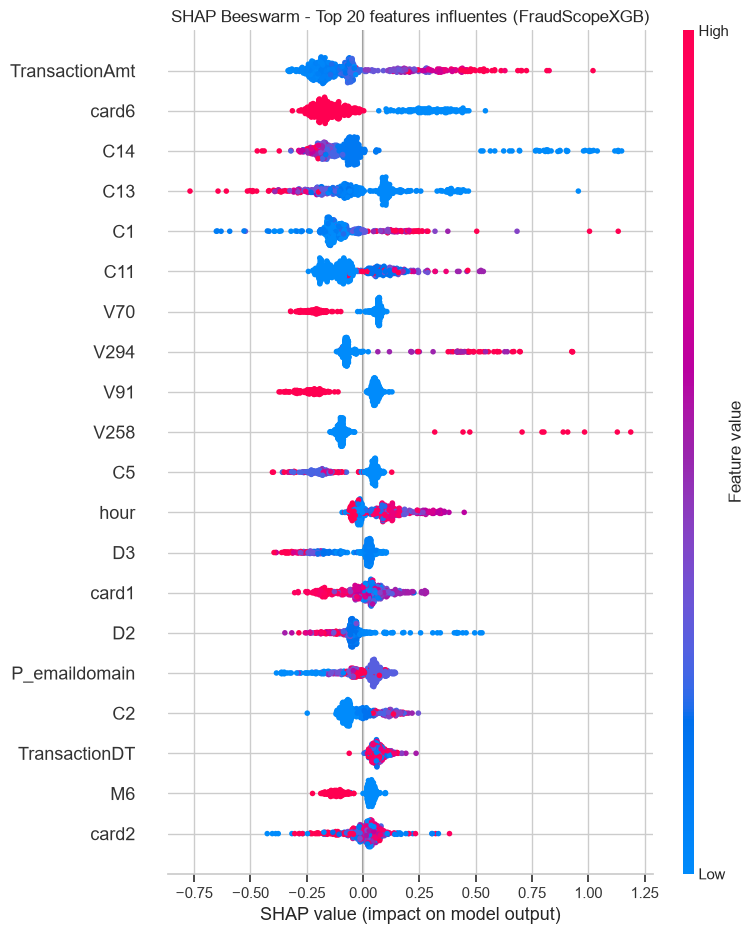

Beeswarm logge dans MLflow et sauvegarde dans figures/


In [14]:
shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names, max_display=20, plot_type='dot', show=False)
plt.title('SHAP Beeswarm - Top 20 features influentes (FraudScopeXGB)')
plt.tight_layout()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_figure(plt.gcf(), 'shap_beeswarm.png')

plt.savefig(FIGURES_DIR / 'shap_beeswarm_phase2.png', dpi=150)
plt.show()
print('Beeswarm logge dans MLflow et sauvegarde dans figures/')

Vrai positif (index 72) : P(fraude)=0.7353


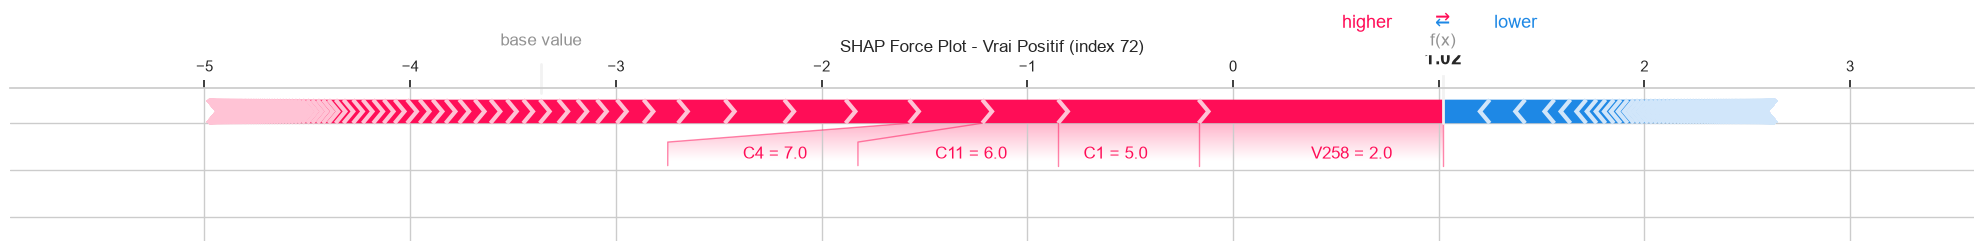

In [15]:
y_holdout_vals = y_holdout.values[:N_SHAP]
y_proba_shap   = loaded_model.predict_proba(X_shap)[:, 1]
tp_indices     = np.where((y_holdout_vals == 1) & (y_proba_shap >= 0.5))[0]

if len(tp_indices) > 0:
    idx_tp = tp_indices[0]
    print(f'Vrai positif (index {idx_tp}) : P(fraude)={y_proba_shap[idx_tp]:.4f}')
    shap.force_plot(explainer.expected_value, shap_values[idx_tp],
                   features=X_shap[idx_tp], feature_names=feature_names,
                   matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot - Vrai Positif (index {idx_tp})')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'shap_force_vrai_positif.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Pas de vrai positif dans les 500 premieres transactions du holdout. Augmenter N_SHAP.')

## 8. Bilan Phase 2

| Element | Statut |
|---------|--------|
| Serveur MLflow local | ✅ |
| Holdout temporel 20% réservé | ✅ |
| TimeSeriesSplit(n_splits=5) sur les 80% restants | ✅ |
| Ratio d'imbalance recalculé par fold dans apply_resampling | ✅ |
| Logging MLflow par step (folds 1-5 + agrégées CV step 6 + holdout step 7) | ✅ |
| 5 strategies XGBoost — métriques agrégées (AUPRC_cv_mean ± std) | ✅ |
| Courbes PR artefacts MLflow (holdout) | ✅ |
| Meilleur modele dans Registry | ✅ |
| Validation gate AUPRC | ✅ |
| Serving REST `/invocations` | ✅ |
| SHAP beeswarm global | ✅ |
| SHAP force plot local | ✅ |

**Prochaine etape** : Phase 3 - Features graphe (NetworkX) + GNN sur dataset Elliptic (GCN/GAT via PyTorch Geometric).

Le notebook `03_graphnn.ipynb` reprendra l'entrainement dans Jupyter, sur un dataset different (graphe de transactions Bitcoin).